In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.path as path
import numpy as np

# Create a figure and an axes
fig, ax = plt.subplots(1)

# Create a circle patch
circle = patches.Circle((0, 0), radius=1.0, fc='lightblue', ec='blue', linewidth=2)
ax.add_patch(circle)

# circle
ax.set_aspect('equal', adjustable='box')

# Plot scale
ax.set_xlim([-1.1, 1.1])
ax.set_ylim([-1.1, 1.1])

# Path
points = []
for i in range(30):
  candidate = (np.random.uniform(-1, 1), np.random.uniform(-1, 1))
  while candidate[0]**2 + candidate[1]**2 >= 1:
    candidate = (np.random.uniform(-1, 1), np.random.uniform(-1, 1))
  points.append(candidate)

#Patch from path
patchPath = path.Path(points, closed = True).cleaned(curves=True)
splat = patches.PathPatch(path=patchPath, facecolor='red')
ax.add_patch(splat)

ax.set_title('Map')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')

plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.path as path
import numpy as np




Matplotlib is building the font cache; this may take a moment.


saved perlin_splats.png


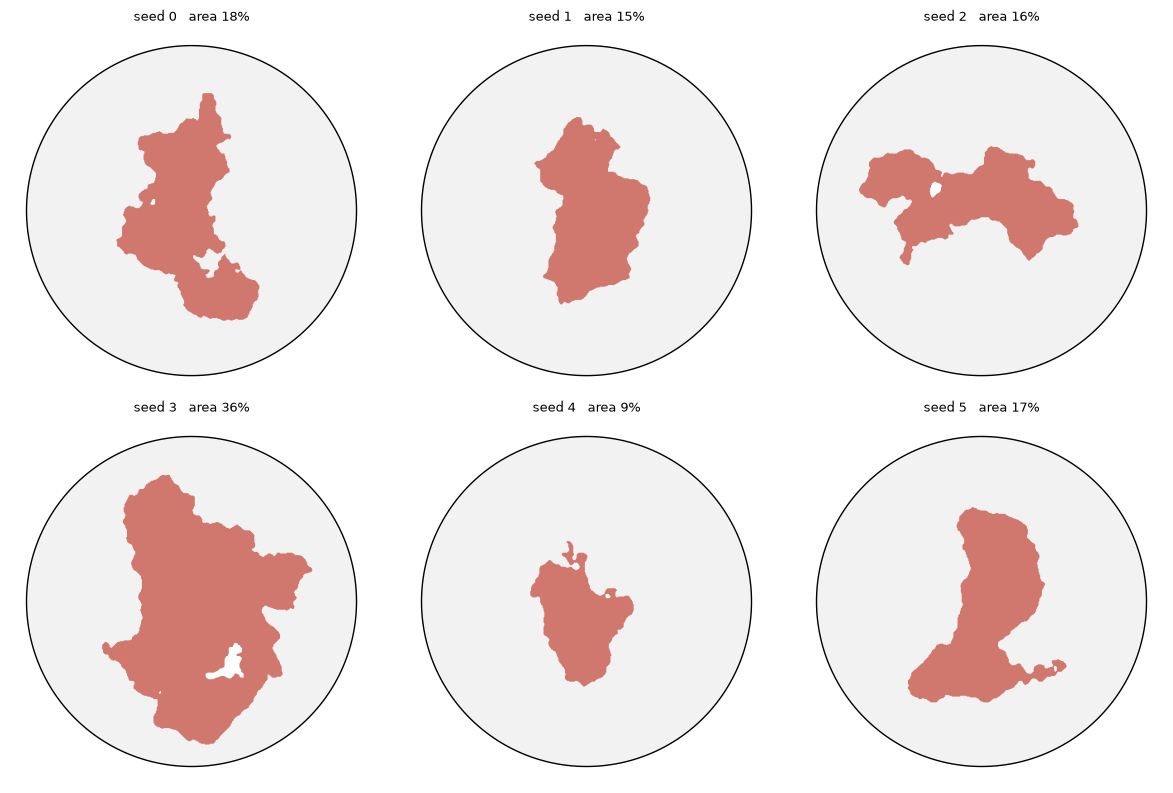

In [3]:

import numpy as np
from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union
from skimage import measure

QUAD = 64


def _perlin_grid(res, rng):
    ry, rx = res
    H, W = _perlin_grid.shape

    # corner gradients
    ang = 2 * np.pi * rng.random((ry + 1, rx + 1))
    grad = np.dstack((np.cos(ang), np.sin(ang)))

    # sample coords
    ys = np.linspace(0, ry, H, endpoint=False)
    xs = np.linspace(0, rx, W, endpoint=False)
    gy, gx = np.meshgrid(ys, xs, indexing="ij")

    y0 = gy.astype(int); x0 = gx.astype(int)
    fy = gy - y0;        fx = gx - x0

    def dot(iy, ix, oy, ox):
        g = grad[(y0 + iy), (x0 + ix)]
        return g[..., 0] * (fy - oy) + g[..., 1] * (fx - ox)

    n00 = dot(0, 0, 0, 0)
    n01 = dot(0, 1, 0, 1)
    n10 = dot(1, 0, 1, 0)
    n11 = dot(1, 1, 1, 1)

    def fade(t):
        return 6 * t**5 - 15 * t**4 + 10 * t**3

    u = fade(fx); v = fade(fy)
    top = n00 * (1 - u) + n01 * u
    bot = n10 * (1 - u) + n11 * u
    return top * (1 - v) + bot * v


def fractal_noise(shape, rng, octaves=5, base_res=3, persistence=0.5, lacunarity=2):

    _perlin_grid.shape = shape
    field = np.zeros(shape)
    amp = 1.0
    freq = base_res
    norm = 0.0
    for _ in range(octaves):
        field += amp * _perlin_grid((freq, freq), rng)
        norm += amp
        amp *= persistence
        freq = int(freq * lacunarity)
    return field / norm

def _mask_to_polygons(field, level, extent):

    H, W = field.shape
    minx, maxx, miny, maxy = extent
    mask = np.pad((field > level).astype(float), 1, constant_values=0.0)

    loops = []
    for c in measure.find_contours(mask, 0.5):

        rr = c[:, 0] - 1
        cc = c[:, 1] - 1
        x = minx + (cc / (W - 1)) * (maxx - minx)
        y = miny + (rr / (H - 1)) * (maxy - miny)
        ring = Polygon(np.column_stack([x, y]))
        if ring.is_valid and ring.area > 0:
            loops.append(ring)

    if not loops:
        return Polygon()
    reps = [lp.representative_point() for lp in loops]
    depth = [sum(other.contains(reps[i]) for k, other in enumerate(loops) if k != i)
             for i in range(len(loops))]
    shells = [i for i in range(len(loops)) if depth[i] % 2 == 0]
    holes = [i for i in range(len(loops)) if depth[i] % 2 == 1]

    polys = []
    for i in shells:
        my_holes = []
        for h in holes:
            if not loops[i].contains(reps[h]):
                continue
            parent = min(
                (s for s in shells if loops[s].contains(reps[h])),
                key=lambda s: loops[s].area,
            )
            if parent == i:
                my_holes.append(np.array(loops[h].exterior.coords))
        polys.append(Polygon(np.array(loops[i].exterior.coords), my_holes))

    return unary_union([p.buffer(0) for p in polys])


def make_perlin_splat(domain,rng,grid=400,
    octaves=5, #lower smoother
    base_res=3,
    persistence=0.5, #lower smoother
    threshold=0.8, # size - higher shirnks
    falloff=1.6,
    min_area_frac=0.01,
):

    R = np.sqrt(domain.area / np.pi)
    field = fractal_noise((grid, grid), rng, octaves=octaves,
                          base_res=base_res, persistence=persistence)

    # normalize to [0, 1]
    field = (field - field.min()) / (np.ptp(field) + 1e-12)

    # subtract a bowl that rises toward the edge
    if falloff > 0:
        lin = np.linspace(-1, 1, grid)
        xx, yy = np.meshgrid(lin, lin)
        rr = np.sqrt(xx**2 + yy**2)
        field = field - (rr ** falloff)
        field = (field - field.min()) / (np.ptp(field) + 1e-12)

    extent = (-R, R, -R, R)
    splat = _mask_to_polygons(field, threshold, extent)
    splat = splat.intersection(domain).buffer(0)

    # keep only good blobs
    if isinstance(splat, MultiPolygon):
        keep = [g for g in splat.geoms if g.area >= min_area_frac * domain.area]
        splat = unary_union(keep) if keep else max(splat.geoms, key=lambda g: g.area)

    return splat




if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from matplotlib.patches import Polygon as MplPolygon
    from shapely.geometry import Point

    def patch(ax, geom, **kw):
        geoms = geom.geoms if geom.geom_type.startswith("Multi") else [geom]
        for g in geoms:
            if g.is_empty:
                continue
            ax.add_patch(MplPolygon(np.array(g.exterior.coords), **kw))
            for ring in g.interiors:
                ax.add_patch(MplPolygon(np.array(ring.coords), facecolor="white", edgecolor="none"))

    domain = Point(0, 0).buffer(1.0, quad_segs=QUAD)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for ax, seed in zip(axes.ravel(), range(6)):
        rng = np.random.default_rng(seed)
        splat = make_perlin_splat(domain, rng)
        patch(ax, domain, facecolor="#f2f2f2", edgecolor="black", linewidth=1.0)
        patch(ax, splat, facecolor="#c44536", edgecolor="none", alpha=0.7)
        ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
        ax.set_aspect("equal"); ax.axis("off")
        ax.set_title(f"seed {seed}   area {splat.area/domain.area:.0%}", fontsize=9)

    fig.tight_layout()
    fig.savefig("perlin_splats.png", dpi=130, bbox_inches="tight")
    print("saved perlin_splats.png")